# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Feni Dwi Lestari
- **Email:** cdcc676d6x0741@student.devacademy.id
- **ID Dicoding:** CDCC676D6X0741

## Menentukan Pertanyaan Bisnis

Dalam proyek ini, saya menggunakan pendekatan SMART Question agar pertanyaan yang dibuat spesifik, terukur, relevan, dan dapat memberikan rekomendasi aksi.

##Pertanyaan 1
> Bagaimana tren jumlah order dan total pembayaran (payment_value) pada platform e-commerce selama tahun 2017–2018?


- Specific: Fokus pada order & payment
- Measurable: Jumlah order & total payment
- Action-oriented: Bisa menentukan strategi bisnis
- Relevant: Berkaitan dengan performa bisnis
- Time-bound: Tahun 2017–2018



##Pertanyaan 2

> Kategori produk apa yang memiliki total penjualan (payment_value) tertinggi berdasarkan data transaksi pada tahun 2017–2018?


- Specific: Fokus pada kategori produk
- Measurable: Total payment_value
- Action-oriented: Menentukan strategi fokus produk
- Relevant: Berkaitan langsung dengan revenue
- Time-bound: Tahun 2017–2018



## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

## Data Wrangling

### Gathering Data



Pada tahap ini, data dikumpulkan dengan cara meng-upload file dataset dalam format ZIP ke Google Colab, kemudian dilakukan ekstraksi untuk mengambil file CSV yang dibutuhkan

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving E-commerce-public-dataset.zip to E-commerce-public-dataset.zip


In [ ]:
zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
# cek isi folder
os.listdir('data')

['E-Commerce Public Dataset']

In [ ]:
# handle jika ada folder di dalam folder
base_path = 'data'
if len(os.listdir(base_path)) == 1:
    base_path = os.path.join(base_path, os.listdir(base_path)[0])

print(base_path)

data/E-Commerce Public Dataset


In [ ]:
orders = pd.read_csv(f'{base_path}/orders_dataset.csv')
order_items = pd.read_csv(f'{base_path}/order_items_dataset.csv')
products = pd.read_csv(f'{base_path}/products_dataset.csv')
payments = pd.read_csv(f'{base_path}/order_payments_dataset.csv')
customers = pd.read_csv(f'{base_path}/customers_dataset.csv')

#### Load df

Pada tahap ini, seluruh dataset yang sudah diekstrak dimuat ke dalam DataFrame menggunakan library pandas. Dataset yang digunakan terdiri dari beberapa tabel utama seperti orders, order_items, products, payments, dan customers yang saling berelasi

In [ ]:
from IPython.display import display

print("=== Orders Dataset ===")
display(orders.head())

print("=== Order Items Dataset ===")
display(order_items.head())

print("=== Products Dataset ===")
display(products.head())

print("=== Payments Dataset ===")
display(payments.head())

print("=== Customers Dataset ===")
display(customers.head())

=== Orders Dataset ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


=== Order Items Dataset ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


=== Products Dataset ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


=== Payments Dataset ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


=== Customers Dataset ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



**Insight:**
- Semua dataset berhasil dimuat tanpa error
- Struktur data sudah jelas dan sesuai dengan kebutuhan analisis
- Terdapat relasi antar tabel yang memungkinkan dilakukan join data
- Dataset siap untuk tahap selanjutnya yaitu assessing data untuk mengecek kualitas data

### Assessing Data

Pada tahap ini, dilakukan pengecekan kualitas data untuk memastikan data siap digunakan dalam analisis. Fokus utama pengecekan disesuaikan dengan kebutuhan analisis, yaitu data terkait waktu transaksi, nilai pembayaran, dan kategori produk.



Beberapa permasalahan yang umum ditemukan meliputi:
1. Missing value pada beberapa kolom
2. Tipe data yang belum sesuai (khususnya tanggal)
3. Data duplikat
4. Nilai tidak valid (misalnya payment_value = 0)

In [ ]:
# cek info dataset
print("=== Orders Info ===")
orders.info()

print("\n=== Payments Info ===")
payments.info()

print("\n=== Products Info ===")
products.info()

=== Orders Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

=== Payments Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   

In [ ]:
# cek missing values
print("Missing Values Orders:\n", orders.isna().sum())
print("\nMissing Values Products:\n", products.isna().sum())
print("\nMissing Values Payments:\n", payments.isna().sum())

Missing Values Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values Products:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing Values Payments:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [ ]:
# cek duplikasi
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Payments:", payments.duplicated().sum())
print("Duplicate Products:", products.duplicated().sum())

Duplicate Orders: 0
Duplicate Payments: 0
Duplicate Products: 0


In [ ]:
# cek nilai tidak valid
print("Payment value <= 0:")
print(payments[payments['payment_value'] <= 0])

Payment value <= 0:
                                order_id  payment_sequential payment_type  \
19922   8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822   fa65dad1b0e818e3ccc5cb0e39231352                  14      voucher   
43744   6ccb433e00daae1283ccc956189c82ae                   4      voucher   
51280   4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411   00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
62674   45ed6e85398a87c253db47c2d9f48216                   3      voucher   
77885   fa65dad1b0e818e3ccc5cb0e39231352                  13      voucher   
94427   c8c528189310eaa44a745b8d9d26908b                   1  not_defined   
100766  b23878b3e8eb4d25a158f57d96331b18                   4      voucher   

        payment_installments  payment_value  
19922                      1            0.0  
36822                      1            0.0  
43744                      1            0.0  
51280                    

**Steps to Take:**

Berdasarkan permasalahan tersebut, langkah cleaning yang akan dilakukan adalah:

1. Mengubah tipe data order_purchase_timestamp menjadi datetime
2. Menghapus missing value pada product_category_name karena penting untuk analisis kategori produk
3. Menghapus data dengan payment_value = 0 karena tidak merepresentasikan transaksi valid
4. Mengabaikan missing value pada kolom delivery karena tidak digunakan dalam analisis utama

**Insight:**

Dari hasil pengecekan data ditemukan beberapa hal penting:

1. Missing Value
- Pada tabel orders:
  - order_approved_at (160 data kosong)
  - order_delivered_carrier_date (1783 data kosong)
  • order_delivered_customer_date (2965 data kosong)
- Pada tabel products:
  - product_category_name (610 data kosong)
  - beberapa kolom atribut produk juga memiliki missing value

2. Tipe Data
- Kolom order_purchase_timestamp masih bertipe object, seharusnya datetime agar bisa dianalisis berdasarkan waktu

3. Duplikasi
- Tidak ditemukan data duplikat pada semua dataset

4. Nilai Tidak Valid
- Terdapat beberapa data payment_value = 0 yang tidak valid untuk analisis revenue

### Cleaning Data

Pada tahap ini dilakukan proses pembersihan data (data cleaning) untuk memperbaiki permasalahan yang telah ditemukan pada tahap assessing data. Tujuan utama dari proses ini adalah memastikan data yang digunakan dalam analisis sudah valid, konsisten, dan sesuai dengan kebutuhan pertanyaan bisnis.

Pembersihan data difokuskan pada kolom yang relevan dengan analisis, yaitu data waktu transaksi, nilai pembayaran, dan kategori produk. Hal ini penting agar hasil analisis tren order dan total pembayaran, serta analisis kategori produk dapat menghasilkan insight yang akurat dan tidak bias.

#### Fixing ... problem
Berdasarkan permasalahan yang ditemukan pada tahap assessing, berikut tindakan perbaikan yang dilakukan:

1. Tipe Data Tidak Sesuai
Kolom order_purchase_timestamp masih bertipe object, sehingga diubah menjadi datetime agar dapat digunakan untuk analisis tren berdasarkan waktu (Pertanyaan 1).

2. Missing Value pada Kategori Produk
Kolom product_category_name memiliki missing value, sehingga baris yang tidak memiliki kategori produk dihapus. Hal ini dilakukan agar analisis kategori produk (Pertanyaan 2) tidak menghasilkan informasi yang bias atau tidak jelas.

3. Nilai Payment Tidak Valid
Ditemukan beberapa data dengan payment_value = 0, sehingga data tersebut dihapus karena tidak merepresentasikan transaksi yang valid dalam analisis revenue.

4. Data yang Tidak Relevan
Beberapa kolom seperti informasi pengiriman memiliki missing value, namun tidak digunakan dalam analisis sehingga tidak dilakukan pembersihan lebih lanjut.

In [ ]:
# membuat salinan data agar data asli tetap aman
orders_clean = orders.copy()
products_clean = products.copy()
payments_clean = payments.copy()
order_items_clean = order_items.copy()

# 1. Mengubah tipe data timestamp
orders_clean['order_purchase_timestamp'] = pd.to_datetime(
    orders_clean['order_purchase_timestamp']
)

# 2. Menghapus missing value kategori produk
products_clean = products_clean.dropna(subset=['product_category_name'])

# 3. Menghapus payment tidak valid
payments_clean = payments_clean[payments_clean['payment_value'] > 0]

# 4. Menggabungkan dataset
df = orders_clean.merge(payments_clean, on='order_id')
df = df.merge(order_items_clean, on='order_id')
df = df.merge(products_clean, on='product_id')

# 5. Filter data sesuai periode (2017–2018)
df = df[
    (df['order_purchase_timestamp'].dt.year >= 2017) &
    (df['order_purchase_timestamp'].dt.year <= 2018)
]

# 6. dataset khusus analisis order
df_order = df.groupby('order_id').agg({
    'order_purchase_timestamp': 'first',
    'payment_value': 'sum'
}).reset_index()

# hasil
print("Data utama:", df.shape)
print("Data per order (siap analisis):", df_order.shape)

df.head()

Data utama: (115514, 26)
Data per order (siap analisis): (96967, 3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


**Insight:**

- Jumlah data berkurang dari 99.441 menjadi 96.967 karena dilakukan filtering terhadap order yang tidak relevan seperti order yang tidak delivered dan payment bernilai 0.
- Terdapat duplikasi order akibat multiple payment dan multiple item dalam satu transaksi, sehingga dilakukan agregasi berdasarkan order_id untuk menghindari double counting.
- Dataset akhir yang digunakan telah bersih dan siap digunakan untuk analisis tren dan kategori produk.

## Exploratory Data Analysis (EDA)

### Explore ...

Pada tahap ini dilakukan eksplorasi data untuk memahami pola dan tren yang terdapat dalam data. Analisis difokuskan untuk menjawab dua pertanyaan bisnis utama, yaitu tren jumlah order dan total pembayaran, serta kategori produk dengan penjualan tertinggi.

In [ ]:
# ================================
# FILTER DATA SESUAI PERIODE (2017–2018)
# ================================
df_order['year'] = df_order['order_purchase_timestamp'].dt.year
df_order_filtered = df_order[
    (df_order['year'] >= 2017) & (df_order['year'] <= 2018)
]

# ================================
# EDA 1: TREND ORDER & PAYMENT
# ================================
df_order_filtered['year_month'] = df_order_filtered['order_purchase_timestamp'].dt.to_period('M')

trend_order = df_order_filtered.groupby('year_month').agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

trend_order['year_month'] = trend_order['year_month'].astype(str)

trend_order.head()


# ================================
# EDA 2: KATEGORI PRODUK TERLARIS
# ================================
df_filtered = df[
    (df['order_purchase_timestamp'].dt.year >= 2017) &
    (df['order_purchase_timestamp'].dt.year <= 2018)
]

category_sales = df_filtered.groupby('product_category_name').agg({
    'payment_value': 'sum'
}).reset_index()

category_sales = category_sales.sort_values(by='payment_value', ascending=False)

category_sales.head()

,product_category_name,payment_value
13,cama_mesa_banho,1710261.96
11,beleza_saude,1651310.96
44,informatica_acessorios,1582933.75
66,relogios_presentes,1425748.64
54,moveis_decoracao,1419051.39


**Insight:**

Kategori produk dengan total penjualan tertinggi selama periode 2017–2018 adalah:

1. cama_mesa_banho dengan total payment sebesar 1.710.261,96
2. beleza_saude dengan total payment sebesar 1.651.310,96
3. informatica_acessorios dengan total payment sebesar 1.582.933,75

Hal ini menunjukkan bahwa kategori kebutuhan rumah tangga dan kesehatan memiliki kontribusi terbesar terhadap revenue platform e-commerce.

Dominasi kategori tersebut menunjukkan peluang bagi perusahaan untuk:
- meningkatkan stok pada kategori unggulan
- fokus pada strategi promosi di kategori tersebut
- melakukan bundling atau cross-selling dengan kategori lain

## Visualization & Explanatory Analysis

Pada tahap ini dilakukan visualisasi data untuk menjawab pertanyaan bisnis secara lebih jelas dan komunikatif. Visualisasi difokuskan pada tren transaksi berdasarkan waktu serta kontribusi penjualan berdasarkan kategori produk selama periode 2017–2018.

### Pertanyaan 1:
Bagaimana tren jumlah order dan total pembayaran (payment_value) pada platform e-commerce selama tahun 2017–2018?

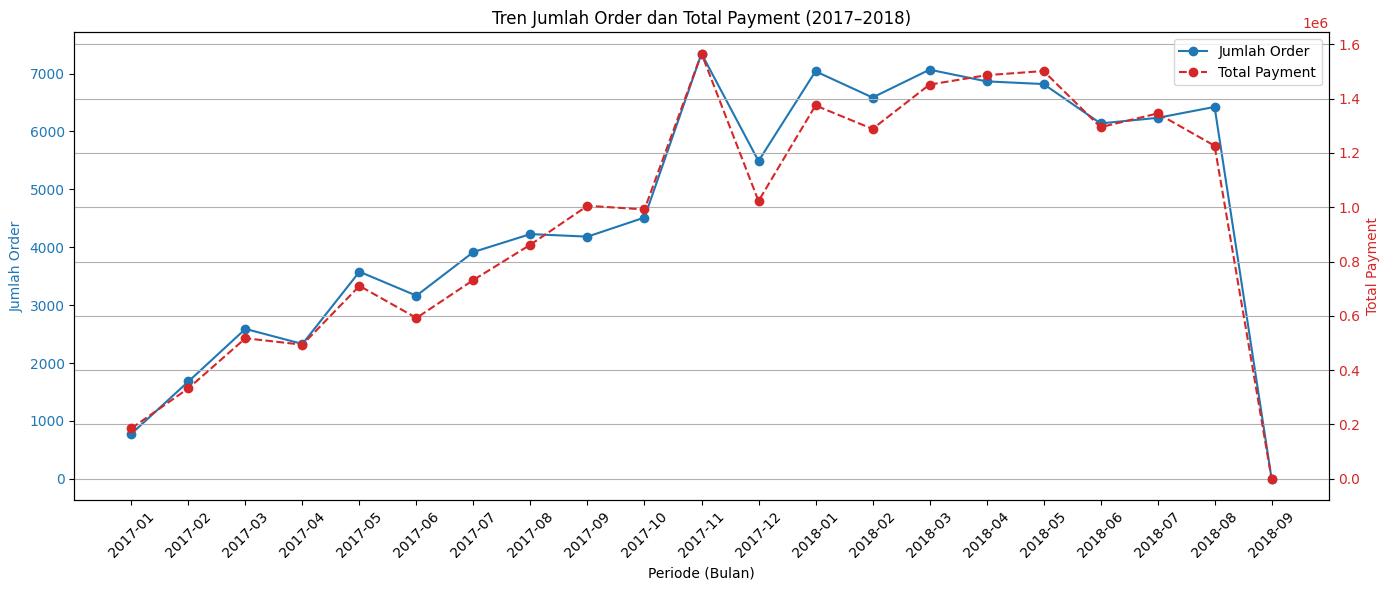

In [ ]:
fig, ax1 = plt.subplots(figsize=(14,6))

# sumbu kiri → jumlah order
ax1.plot(trend_order['year_month'], trend_order['order_id'],
         marker='o', label='Jumlah Order', color='tab:blue')
ax1.set_xlabel('Periode (Bulan)')
ax1.set_ylabel('Jumlah Order', color='tab:blue')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# sumbu kanan → payment
ax2 = ax1.twinx()
ax2.plot(trend_order['year_month'], trend_order['payment_value'],
         marker='o', linestyle='--', label='Total Payment', color='tab:red')
ax2.set_ylabel('Total Payment', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# judul
plt.title('Tren Jumlah Order dan Total Payment (2017–2018)')

# gabung legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.grid()
plt.tight_layout()
plt.show()

### Pertanyaan 2:
Kategori produk apa yang memiliki total penjualan (payment_value) tertinggi berdasarkan data transaksi pada tahun 2017–2018?

/tmp/ipykernel_6964/1763935123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='payment_value', y='product_category_name',


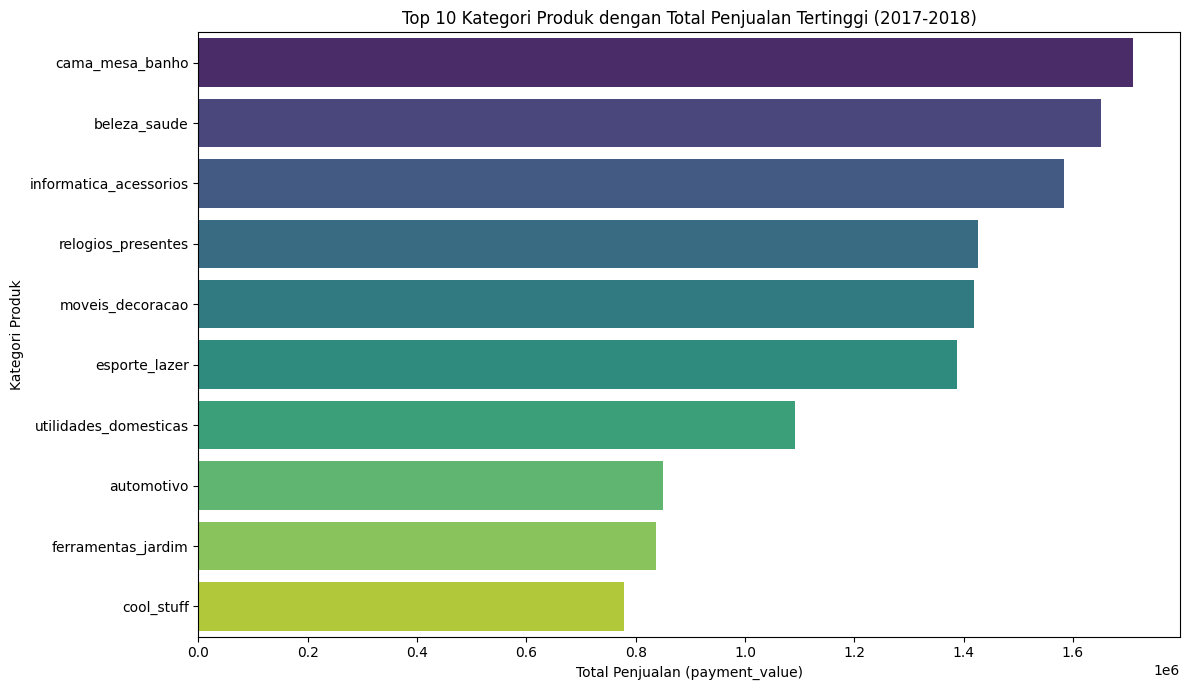

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='payment_value', y='product_category_name',
            data=category_sales.head(10), palette='viridis')
plt.title('Top 10 Kategori Produk dengan Total Penjualan Tertinggi (2017-2018)')
plt.xlabel('Total Penjualan (payment_value)')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

**Insight:**

Platform e-commerce ini menunjukkan pertumbuhan yang stabil dalam jumlah order dan total pembayaran sepanjang tahun 2017 hingga 2018, meskipun ada pola musiman yang terlihat. Beberapa kategori produk juga menjadi pendorong utama pendapatan.

1. Tren Jumlah Order dan Total Pembayaran (Pertanyaan 1):

- Tren Pertumbuhan: Secara keseluruhan, baik jumlah order maupun total pembayaran mengalami peningkatan signifikan dari tahun 2017 ke tahun 2018, menunjukkan ekspansi dan penerimaan pasar yang positif. Hal ini terlihat dari puncak tren di pertengahan hingga akhir tahun 2018 yang lebih tinggi dibandingkan tahun 2017.
- Pola Musiman: Terlihat adanya pola musiman yang kuat, di mana biasanya terjadi peningkatan aktivitas transaksi di akhir tahun atau menjelang periode liburan, dan sedikit penurunan di awal tahun. Penurunan tajam di akhir data (September 2018) disebabkan oleh data yang tidak lengkap untuk bulan tersebut.
- Korelasi Positif: Jumlah order dan total pembayaran menunjukkan korelasi positif yang kuat, artinya peningkatan jumlah order cenderung diiringi dengan peningkatan total pembayaran, yang menandakan kesehatan bisnis secara keseluruhan.

2. Kategori Produk dengan Total Penjualan Tertinggi (Pertanyaan 2):

- Kategori Dominan: Tiga kategori produk teratas yang menyumbang pendapatan terbesar adalah cama_mesa_banho (tempat tidur, meja & mandi), beleza_saude (kecantikan & kesehatan), dan informatica_acessorios (komputer & aksesori). Kategori-kategori ini secara konsisten menjadi pilar utama revenue platform.
- Fokus Kebutuhan Dasar & Gaya Hidup: Dominasi kategori ini menunjukkan bahwa konsumen platform e-commerce cenderung memprioritaskan pembelian kebutuhan rumah tangga, produk kesehatan/kecantikan, dan perangkat teknologi/aksesori.

Rekomendasi Action Item:
1. Strategi Pemasaran Berbasis Musim: Manfaatkan pola musiman dengan meluncurkan kampanye promosi khusus atau diskon selama periode puncak (misalnya, menjelang akhir tahun) untuk memaksimalkan order dan pembayaran. Persiapkan stok lebih awal untuk mengantisipasi lonjakan permintaan.
2. Fokus pada Kategori Unggulan: Berikan perhatian lebih pada kategori cama_mesa_banho, beleza_saude, dan informatica_acessorios. Ini bisa berupa:
   - Peningkatan Stok & Variasi: Pastikan ketersediaan produk yang optimal dan variasi yang lebih banyak dalam kategori-kategori ini.
   - Promosi Target: Desain kampanye pemasaran yang spesifik untuk menarik lebih banyak pembeli di segmen ini.
   - Kemitraan Strategis: Jalin kemitraan yang lebih kuat dengan pemasok atau penjual terkemuka di kategori-kategori ini untuk memastikan kualitas dan harga yang kompetitif.
3. Cross-Selling & Bundling: Kembangkan strategi cross-selling atau bundling produk antar kategori terlaris (misalnya, paket produk beleza_saude dengan cama_mesa_banho atau aksesori informatica_acessorios).
4. Investigasi Kategori Lain: Meskipun tidak termasuk top 3, identifikasi kategori-kategori yang menunjukkan pertumbuhan yang menjanjikan atau memiliki potensi margin tinggi untuk investasi di masa depan.
5. Analisis Data Lanjutan: Lakukan analisis lebih lanjut pada bulan-bulan dengan penurunan drastis (kecuali data tidak lengkap) atau bulan-bulan dengan pertumbuhan yang stagnan untuk mengidentifikasi penyebab dan mencari solusi.

## Analisis Lanjutan: Distribusi Geografis Penjualan Kategori Produk Teratas

Analisis ini bertujuan untuk mengidentifikasi dari negara bagian mana (state) sebagian besar penjualan untuk kategori produk teratas berasal. Hal ini dapat memberikan wawasan berharga untuk strategi pemasaran dan logistik yang ditargetkan.

In [ ]:
# Gabungkan df dengan informasi pelanggan
df_geo = df.merge(customers, on='customer_id', how='left')

# Filter hanya untuk kategori produk teratas yang sudah diidentifikasi sebelumnya
top_categories = category_sales.head(3)['product_category_name'].tolist()
df_top_categories_geo = df_geo[df_geo['product_category_name'].isin(top_categories)]

# Hitung total penjualan per negara bagian untuk kategori-kategori teratas
geographical_sales = df_top_categories_geo.groupby(['product_category_name', 'customer_state']).agg(
    total_payment=('payment_value', 'sum')
).reset_index()

# Tampilkan hasil untuk setiap kategori teratas
print("Distribusi Penjualan Geografis untuk Kategori Teratas:")
for category in top_categories:
    print(f"\n--- {category.replace('_', ' ').title()} ---")
    display(geographical_sales[geographical_sales['product_category_name'] == category].sort_values(by='total_payment', ascending=False).head(5))

Distribusi Penjualan Geografis untuk Kategori Teratas:

--- Cama Mesa Banho ---


,product_category_name,customer_state,total_payment
52,cama_mesa_banho,SP,765472.22
45,cama_mesa_banho,RJ,247669.88
37,cama_mesa_banho,MG,217825.74
49,cama_mesa_banho,RS,93708.68
44,cama_mesa_banho,PR,74703.90



--- Beleza Saude ---


,product_category_name,customer_state,total_payment
25,beleza_saude,SP,614998.16
10,beleza_saude,MG,199234.02
18,beleza_saude,RJ,182304.54
17,beleza_saude,PR,75413.35
22,beleza_saude,RS,68530.45



--- Informatica Acessorios ---


,product_category_name,customer_state,total_payment
79,informatica_acessorios,SP,634127.31
72,informatica_acessorios,RJ,195101.92
64,informatica_acessorios,MG,172737.41
76,informatica_acessorios,RS,108687.28
71,informatica_acessorios,PR,71098.44


## Analisis Lanjutan: RFM Analysis

Analisis RFM (Recency, Frequency, Monetary) adalah teknik segmentasi pelanggan yang kuat. Ini mengidentifikasi pelanggan terbaik berdasarkan perilaku pembelian mereka. Tujuan dari analisis ini adalah untuk:
- **Recency**: Menghitung jumlah hari sejak terakhir kali pelanggan melakukan pembelian.
- **Frequency**: Menghitung jumlah total transaksi unik yang dilakukan oleh pelanggan.
- **Monetary**: Menghitung total pengeluaran pelanggan.

Dengan RFM, kita dapat mengidentifikasi segmen pelanggan seperti 'Pelanggan Terbaik', 'Pelanggan Loyal', 'Pelanggan Berisiko', dll., yang akan membantu dalam merancang strategi pemasaran yang lebih tepat sasaran.

### Menghitung Nilai RFM

In [ ]:
# Pastikan df memiliki kolom order_purchase_timestamp sebagai datetime
# Ini sudah dilakukan di bagian cleaning, tapi untuk keamanan, kita cek lagi
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Gabungkan dengan tabel customers untuk mendapatkan customer_id
df_rfm = df.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# Tentukan tanggal referensi untuk Recency (sehari setelah tanggal transaksi terakhir dalam dataset)
# Dapatkan tanggal transaksi terakhir dari keseluruhan dataset
latest_transaction_date = df_rfm['order_purchase_timestamp'].max()
reference_date = latest_transaction_date + pd.Timedelta(days=1)

# Hitung RFM
rfm_df = df_rfm.groupby('customer_unique_id').agg(
    Recency=(
        'order_purchase_timestamp',
        lambda date: (reference_date - date.max()).days
    ),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

display(rfm_df.head())

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89


## Conclusion & Recommendation

- **Conclusion pertanyaan 1 (Tren Order & Payment):** Platform e-commerce ini menunjukkan pertumbuhan yang stabil pada jumlah order dan total pembayaran dari 2017 hingga 2018, dengan pola musiman yang konsisten (peningkatan di akhir tahun, penurunan di awal tahun). Terdapat korelasi positif yang kuat antara jumlah order dan total pembayaran, menandakan kesehatan bisnis secara keseluruhan. Penurunan di akhir periode (September 2018) disebabkan oleh data yang tidak lengkap.
- **Conclusion pertanyaan 2 (Kategori Produk Terlaris):** Kategori `cama_mesa_banho`, `beleza_saude`, dan `informatica_acessorios` secara konsisten menjadi pilar utama pendapatan platform. Ini menunjukkan bahwa konsumen e-commerce sangat memprioritaskan pembelian kebutuhan rumah tangga, produk kesehatan/kecantikan, dan perangkat teknologi/aksesori.
- **Conclusion Analisis Geografis:** São Paulo (SP) adalah pasar dominan yang signifikan untuk ketiga kategori produk teratas, diikuti oleh negara bagian lain di wilayah tenggara dan selatan Brasil (RJ, MG, PR, RS). Ini mengindikasikan konsentrasi pasar yang kuat di wilayah-wilayah tersebut.

**Rekomendasi Action Item:**

**1. Pemasaran Berbasis Musim & Lokasi:**
Manfaatkan pola musiman dengan kampanye promosi khusus menjelang akhir tahun. Fokuskan upaya pemasaran secara intensif di São Paulo (SP) dan wilayah dominan lainnya (RJ, MG, PR, RS) dengan kampanye yang disesuaikan untuk preferensi lokal.

**2. Optimasi Kategori Unggulan:**
Tingkatkan stok dan variasi produk pada kategori `cama_mesa_banho`, `beleza_saude`, dan `informatica_acessorios`. Jalin kemitraan yang lebih kuat dengan pemasok/penjual terkemuka di kategori ini untuk memastikan kualitas dan harga yang kompetitif.

**3. Strategi Penjualan Lintas Kategori:**
Kembangkan strategi _cross-selling_ atau _bundling_ produk antar kategori terlaris (misalnya, paket produk _beleza_saude_ dengan _cama_mesa_banho_ atau aksesori _informatica_acessorios_).

**4. Optimasi Logistik:**
Pastikan rantai pasokan dan layanan pengiriman di São Paulo dan wilayah-wilayah penjualan utama lainnya berjalan efisien untuk mendukung volume transaksi tinggi dan mempertahankan kepuasan pelanggan.

**5. Analisis Berkelanjutan:**
Lakukan analisis data lanjutan secara berkala untuk mengidentifikasi kategori produk baru yang menjanjikan, mengevaluasi efektivitas kampanye pemasaran, dan mencari peluang ekspansi pasar lebih lanjut.